K-Nearest Neighbours · Naive Bayes · Feature Scaling

K-Nearest Neighbours (KNN)

KNN is a lazy learning algorithm — it does no explicit training. Instead, it memorises the entire training dataset
and defers all computation to prediction time. When a new data point arrives, KNN searches through all stored
examples, finds the K closest ones, and assigns the majority class label.

The word lazy has a formal meaning here: there is no generalisation step, no learned model parameters, no weight
updates. This is the opposite of eager learners like Logistic Regression or Neural Networks, which train a model
once and discard the training data. KNN keeps everything.

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm generally used for classification but can also be used for regression tasks. It works
by finding the "k" closest data points (neighbors) to a given input and makes a predictions based on the majority class (for classification) or the average
value (for regression). Since KNN makes no assumptions about the underlying data distribution it makes it a non-parametric and instance-based learning
method.

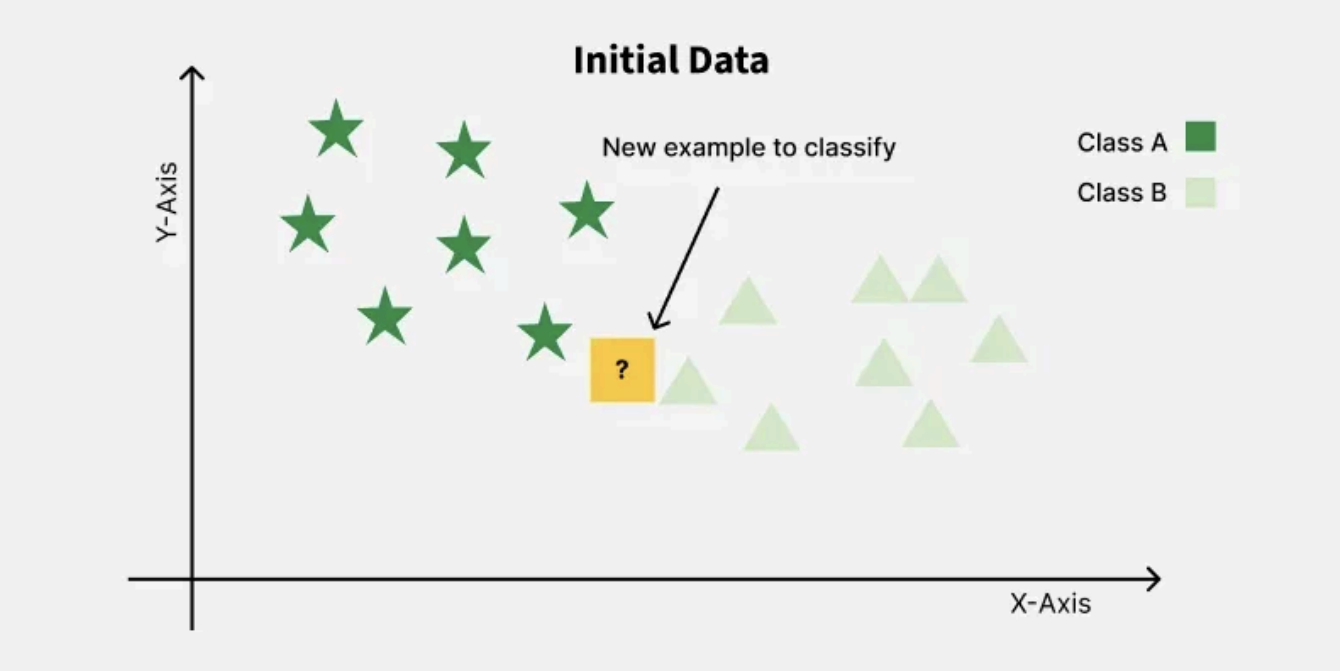

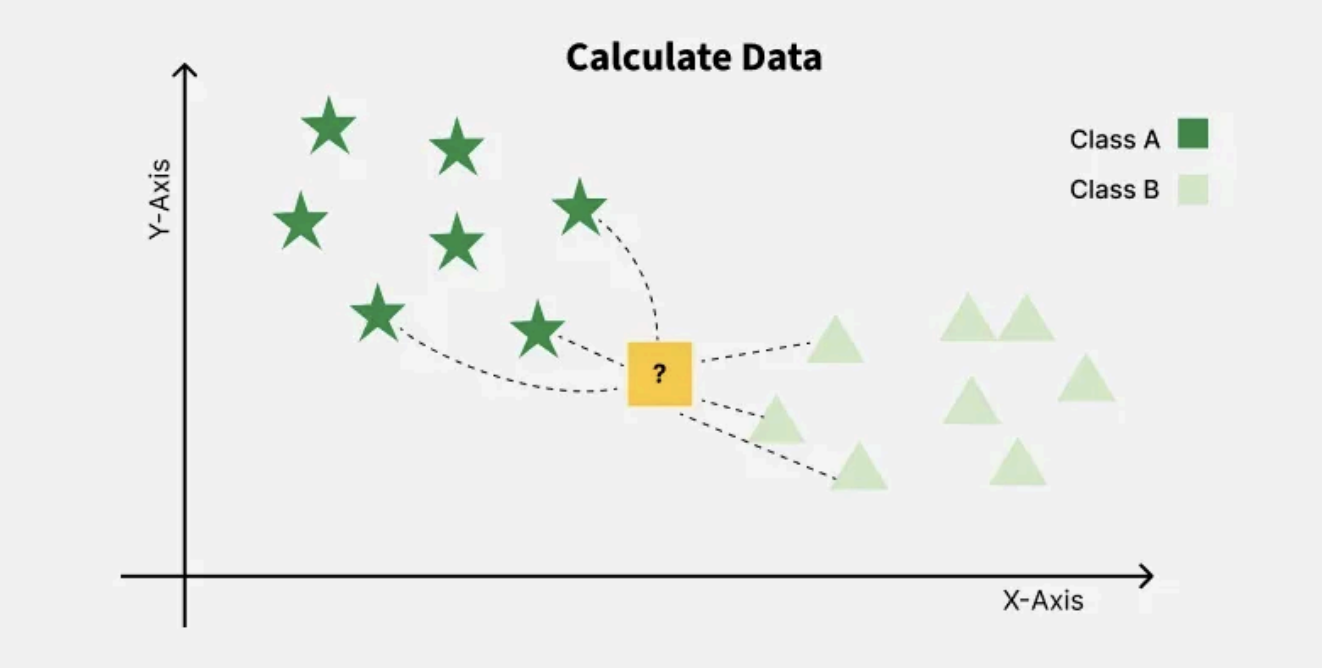

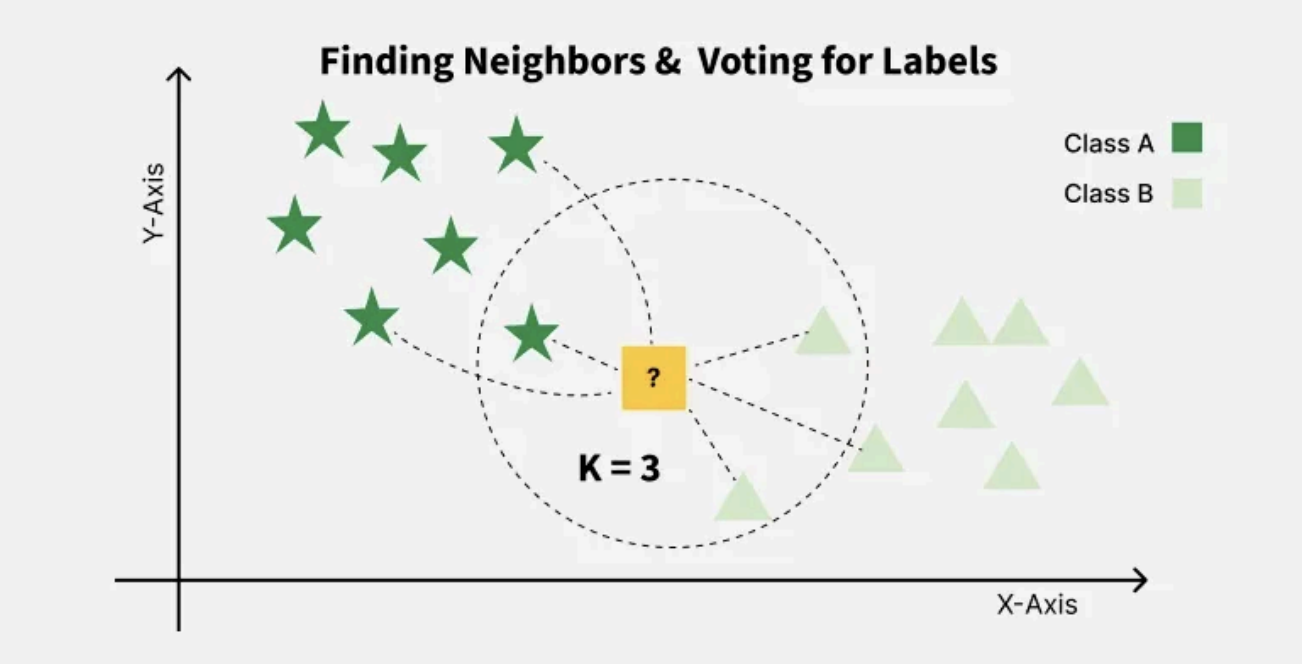

K-Nearest Neighbors is also called as a lazy learner algorithm because it does not learn from the training set immediately instead it stores the entire dataset
and performs computations only at the time of classification.

For example, consider the following table of data points containing two features:

The new point is classified as Category 2 because most of its closest neighbors are red circles. KNN assigns the category based on the majority of nearby
points. The image shows how KNN predicts the category of a new data point based on its closest neighbours.

The blue circles represent Category 1 and the red circles represent Category 2.

The new data point checks its closest neighbors (circled points).

Since the majority of its closest neighbors are red circles (Category 2) KNN predicts the new data point belongs to Category 2.

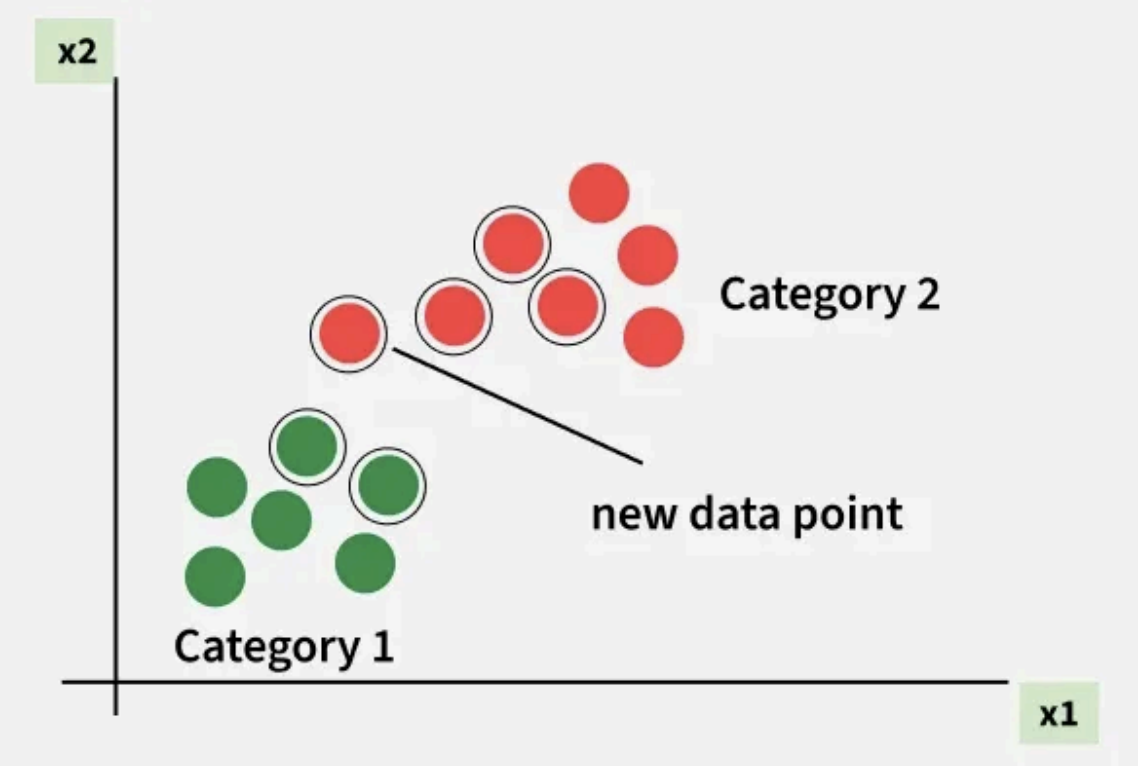

How KNN Works — Step by Step

Step 1 — Compute distances. For each test point, calculate its distance to every training point using a chosen
metric (Euclidean, Manhattan, etc.).

Step 2 — Sort and select. Sort all training points by distance (ascending) and pick the top K.

Step 3 — Vote. For classification, take a majority vote among the K neighbours. For regression, take the mean of
their values.

Step 4 — Assign. The new point receives the winning class label.

What is 'K' in K Nearest Neighbour?

In the k-Nearest Neighbours algorithm k is just a number that tells the algorithm how many nearby points or neighbors to look at when it makes a decision.

Example: Imagine you're deciding which fruit it is based on its shape and size. You compare it to fruits you already know.

If k = 3, the algorithm looks at the 3 closest fruits to the new one.

If 2 of those 3 fruits are apples and 1 is a banana, the algorithm says the new fruit is an apple because most of its neighbors are apples.

How to choose the value of k for KNN Algorithm?

The value of k in KNN decides how many neighbors the algorithm looks at when making a prediction.

Choosing the right k is important for good results.

If the data has lots of noise or outliers, using a larger k can make the predictions more stable.
But if k is too large the model may become too simple and miss important patterns and this is called underfitting.

So k should be picked carefully based on the data.

Statistical Methods for Selecting k

**Cross-Validation:** Cross-Validation is a good way to find the best value of k is by using k-fold cross-validation. This means dividing the dataset
into k parts. The model is trained on some of these parts and tested on the remaining ones. This process is repeated for each part. The k value
that gives the highest average accuracy during these tests is usually the best one to use.

Process

Split data into multiple folds.

Train on some folds.

Test on remaining fold.

Repeat several times.

Compute average accuracy.

Select k with highest average accuracy.

**Cross-validation tests multiple values of k and chooses the one that performs best.**

| k | Average Accuracy |
| - | ---------------- |
| 1 | 88%              |
| 3 | 91%              |
| 5 | 94%              |
| 7 | 93%              |
| 9 | 92%              |


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5)

    print(k, scores.mean())



Elbow Method: In Elbow Method we draw a graph showing the error rate or accuracy for different k values. As k increases the error usually
drops at first. But after a certain point error stops decreasing quickly. The point where the curve changes direction and looks like an "elbow" is
usually the best choice for k.

Odd Values for k: It’s a good idea to use an odd number for k especially in classification problems. This helps avoid ties when deciding which
class is the most common among the neighbors.

Distance Metrics



```
# This is formatted as code
```

KNN uses distance metrics to identify nearest neighbor, these neighbors are used for classification and regression task. To identify nearest neighbor we use
below distance metrics:

| Distance Metric    | Formula                                   | Best Used When                           |
| ------------------ | ----------------------------------------- | ---------------------------------------- |
| Euclidean Distance | Straight-line distance                    | Continuous numerical data                |
| Manhattan Distance | Distance along grid paths                 | Data with outliers or grid-like movement |
| Minkowski Distance | Generalized form of Euclidean & Manhattan | Flexible choice                          |
| Hamming Distance   | Count of mismatched positions             | Binary, categorical, or text data        |


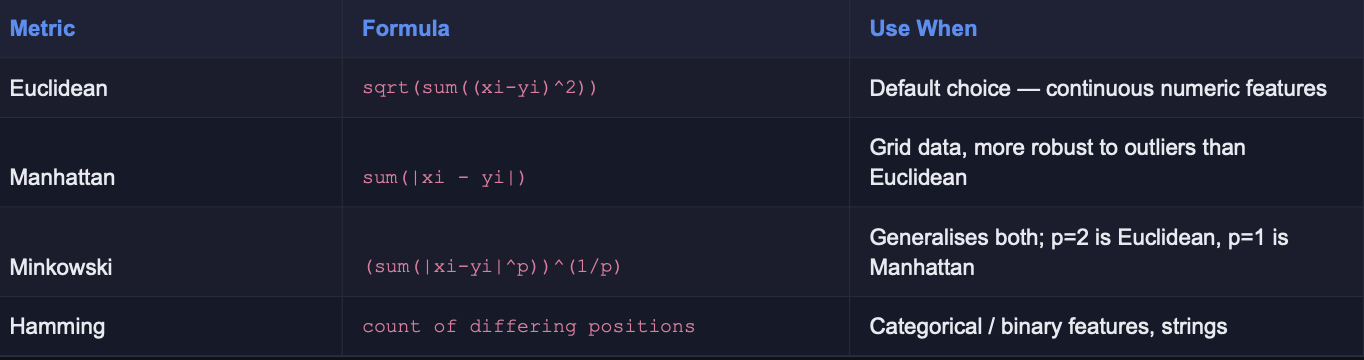

Which Distance Metric Should You Use?

| Data Type                   | Recommended Metric |
| --------------------------- | ------------------ |
| Numeric continuous features | Euclidean          |
| Numeric with outliers       | Manhattan          |
| Want flexibility            | Minkowski          |
| Binary/Categorical data     | Hamming            |


Working of KNN algorithm

Thе K-Nearest Neighbors (KNN) algorithm operates on the principle of similarity where it predicts the label or value of a new data point by considering the
labels or values of its K nearest neighbors in the training dataset.

Step 1: Selecting the optimal value of K

K represents the number of nearest neighbors that needs to be considered while making prediction.

Step 2: Calculating distance

To measure the similarity between target and training data points Euclidean distance is widely used. Distance is calculated between data points
in the dataset and target point.

Step 3: Finding Nearest Neighbors

The k data points with the smallest distances to the target point are nearest neighbors.

Step 4: Voting for Classification or Taking Average for Regression

When you want to classify a data point into a category like spam or not spam, the KNN algorithm looks at the K closest points in the dataset.

These closest points are called neighbors. The algorithm then looks at which category the neighbors belong to and picks the one that appears the
most. This is called majority voting.

In regression, the algorithm still looks for the K closest points. But instead of voting for a class in classification, it takes the average of the
values of those K neighbors. This average is the predicted value for the new point for the algorithm.

It shows how a test point is classified based on its nearest neighbors. As the test point moves the algorithm identifies the closest 'k' data points i.e. 5 in this
case and assigns test point the majority class label that is grey label class here.

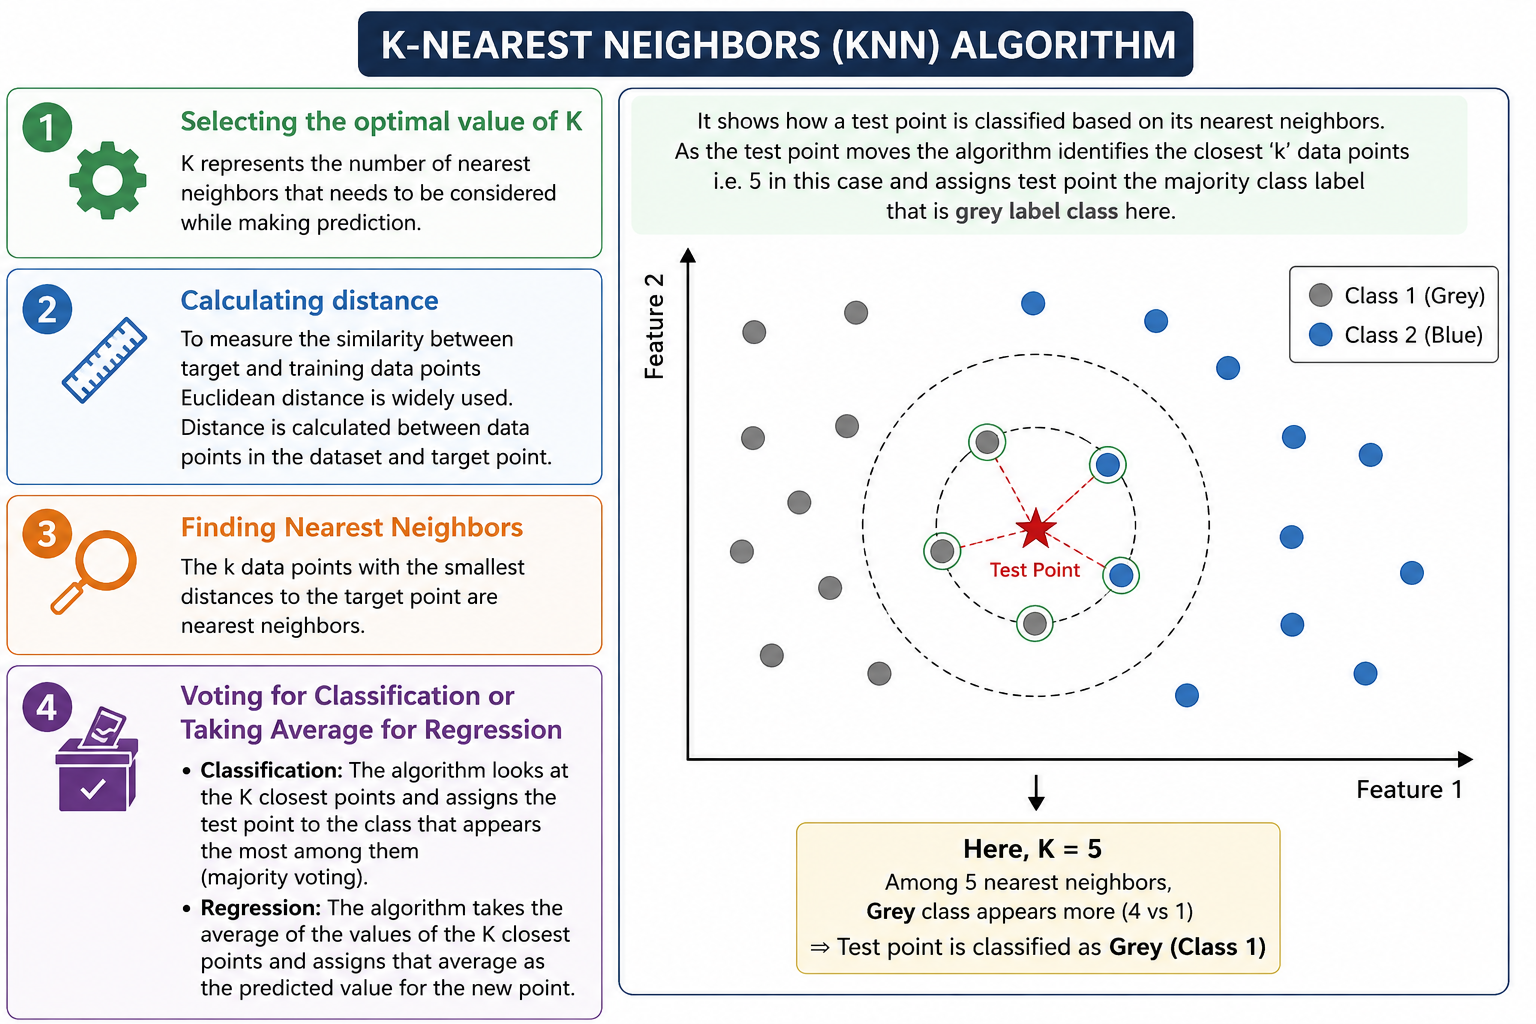

Choosing the Right K

K is the single most important hyperparameter in KNN. There is no universally correct value — it depends on your
dataset. Here is what happens at different extremes:

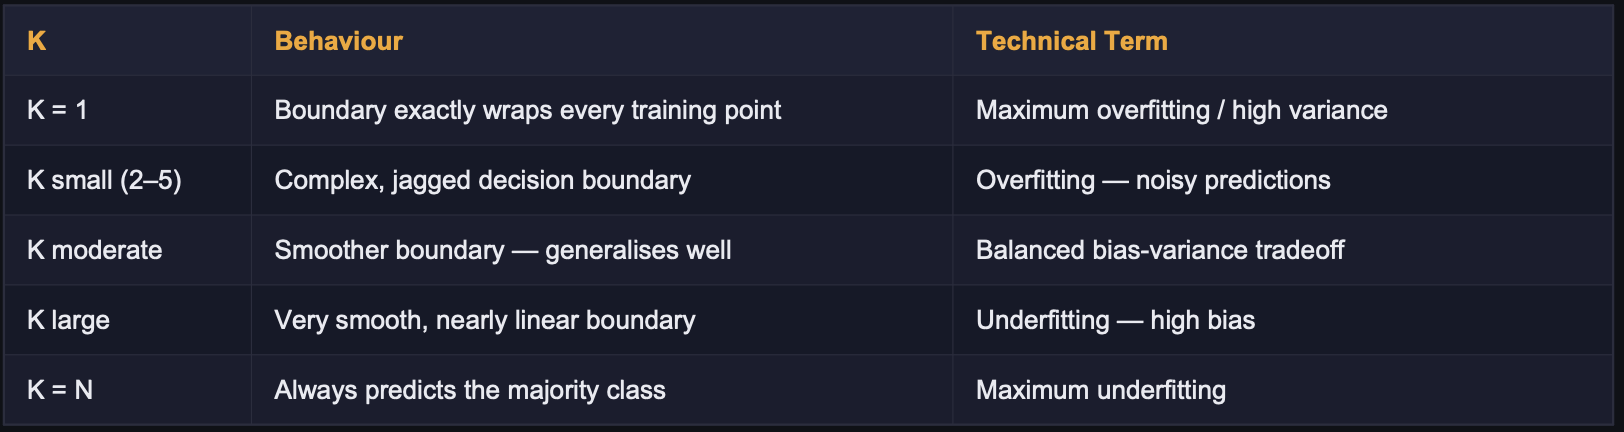

Bias-Variance Tradeoff in KNN

Bias = how wrong your model is on average (underfitting). Variance = how much your model changes with
different training sets (overfitting).

In KNN: small K → low bias, high variance (follows training data too closely). Large K → high bias, low variance
(too generalised). The sweet spot is the K that minimises total error on unseen data — found via
cross-validation.

Strengths and Weaknesses

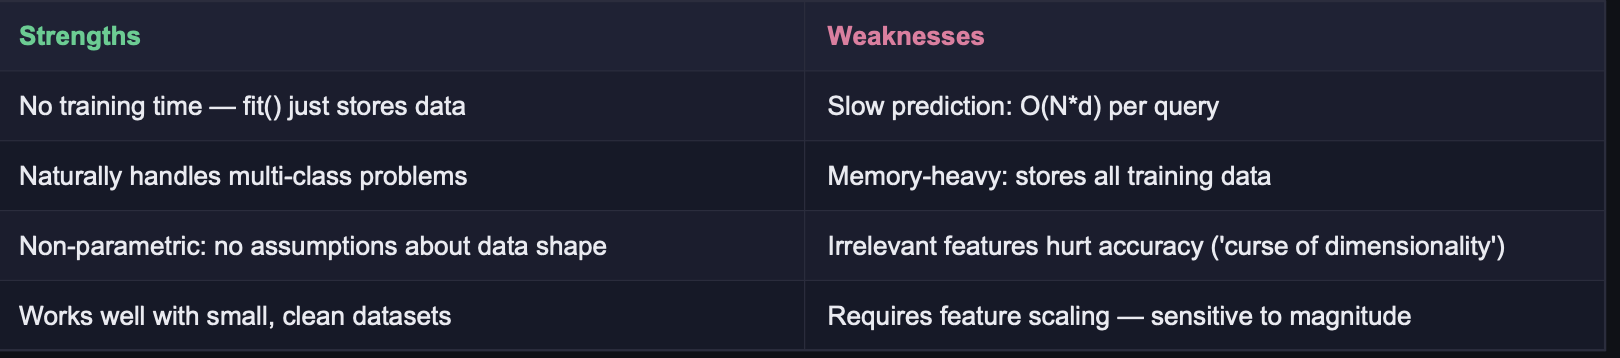

KNN Implementation

In [ ]:
import numpy as np
from collections import Counter # a a a a b b. c c c c c  a:4 b:2 c:5
# ■■ Manual KNN — see exactly what sklearn does ■■■■■■■■■■■■■■■■
class KNNClassifier:
  def __init__(self, k=3):#cons
    self.k = k
  def fit(self, X, y):
    self.X_train = np.array(X) # just store everything
    self.y_train = np.array(y)
  def _euclidean(self, a, b):
    return np.sqrt(np.sum((a - b) ** 2))
  def predict_one(self, x):
    dists = []
    for xt in self.X_train:
      dists.append(
      self._euclidean(x, xt)
      )
    k_idx = np.argsort(dists)[:self.k] # K closest


    k_labels = [self.y_train[i] for i in k_idx]


    return Counter(k_labels).most_common(1)[0][0] # majority vote
  def predict(self, X):
    return [self.predict_one(x) for x in X]

Complete work flow

fit()

    ↓

Store training data

    ↓

predict()

    ↓

For each test point

    ↓

Calculate distances

    ↓

Sort distances

    ↓

Pick K nearest neighbors

    ↓

Collect labels

    ↓

Majority vote

    ↓

Return prediction

In [ ]:
# ■■ sklearn KNN with cross-validation to find best K ■■■■■■■■■■
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

#load data set
iris = load_iris()
X, y = iris.data, iris.target

#split for train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#create a scalar
scaler = StandardScaler()

#scale training data
X_train = scaler.fit_transform(X_train) # fit on train only

#scale test data
X_test = scaler.transform(X_test) # apply same transform to test

# Find best K
k_range = range(1, 33)

# cv for eachk
cv_scores = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5).mean()
    for k in k_range
]
#find best k
best_k = list(k_range)[cv_scores.index(max(cv_scores))]
print(f'Best K={best_k} CV Acc={max(cv_scores):.4f}')

#create final knn model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

Best K=3 CV Acc=0.9500


KNeighborsClassifier(n_neighbors=3)

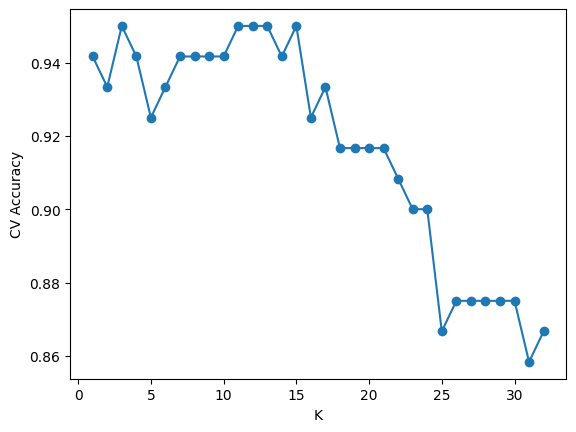

In [ ]:
import matplotlib.pyplot as plt

plt.plot(k_range, cv_scores, marker='o')
plt.xlabel("K")
plt.ylabel("CV Accuracy")
plt.show()

Naive Bayes — Probability Classifier

The Probability Foundation

Unlike KNN which uses geometry, Naive Bayes uses probability theory. It is a generative classifier — it models
the probability distribution of each class and uses that to make predictions. This makes it extremely fast to train (a
single pass through data) and very efficient at prediction time.

Bayes Theorem

Bayes Theorem tells us how to update a prior belief when we observe new evidence:

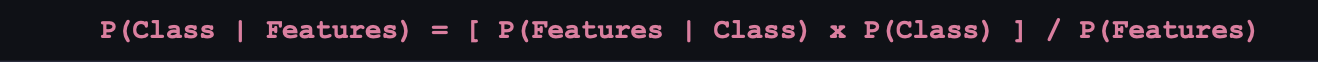

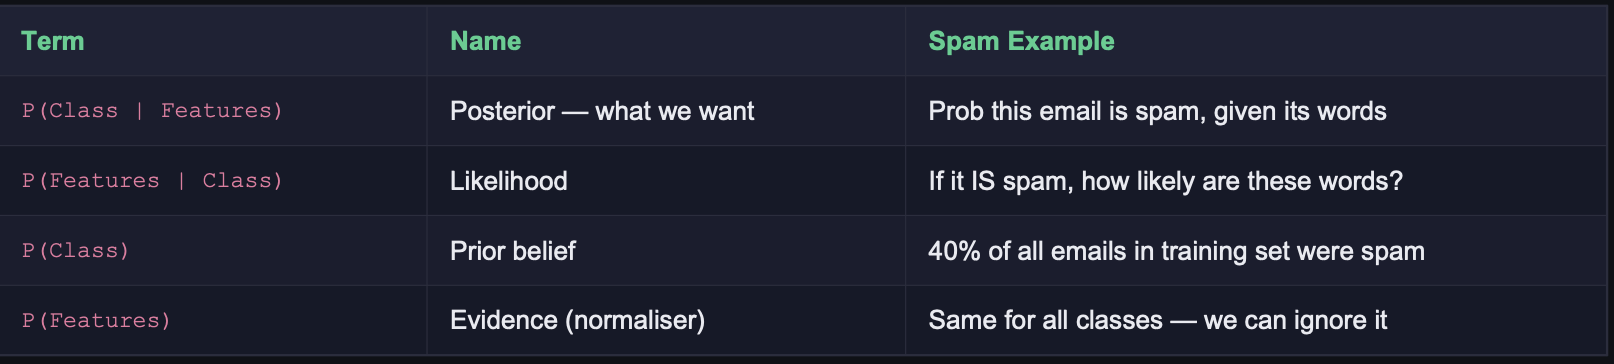

Naive Bayes is a probabilistic machine learning algorithms based on the Bayes Theorem. It is popular method for classification applications such as spam
filtering and text classification.

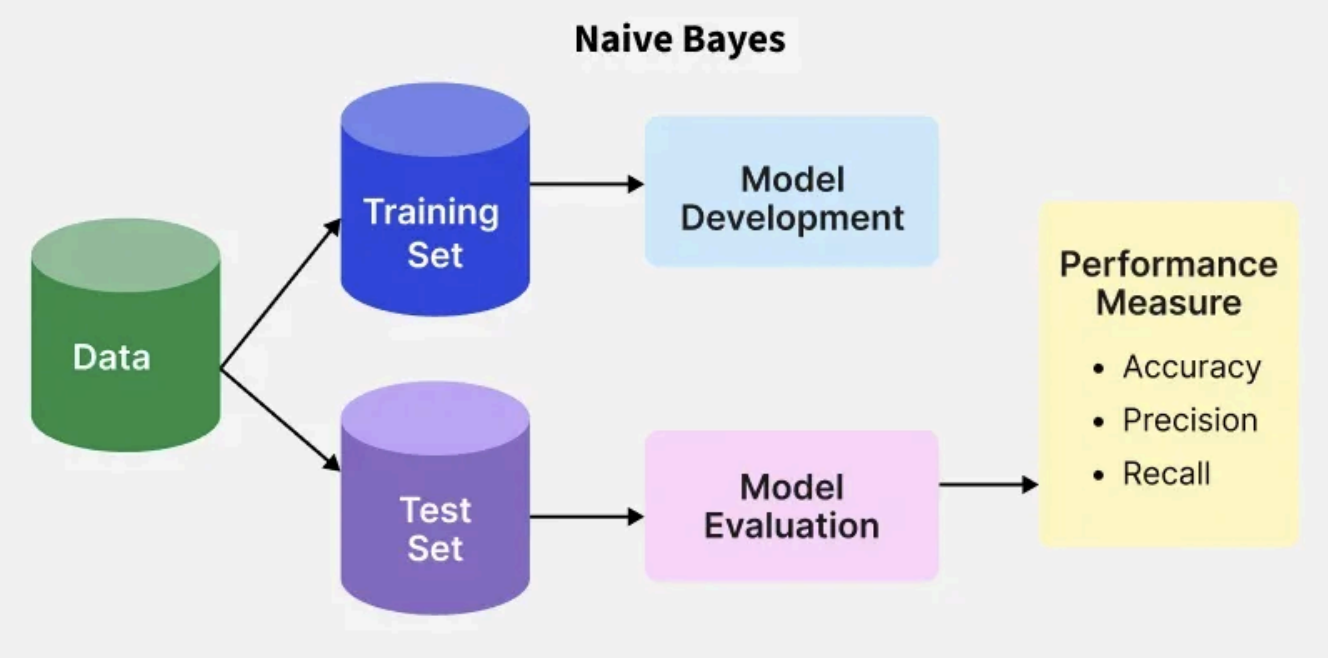

Why Naive? The Independence Assumption

Naive Bayes computes P(Features | Class) by assuming all features are conditionally independent given the
class label. This means:

P(word1, word2, word3 | spam) = P(word1|spam) x P(word2|spam) x P(word3|spam)

In reality, words like 'free' and 'prize' co-occur in spam emails — they are correlated, not independent. The
algorithm ignores this correlation. That is the naive assumption. Despite being technically wrong, it works
remarkably well in text classification because we care about the correct ranking of classes, not the exact probability
values.

Three Flavours of Naive Bayes

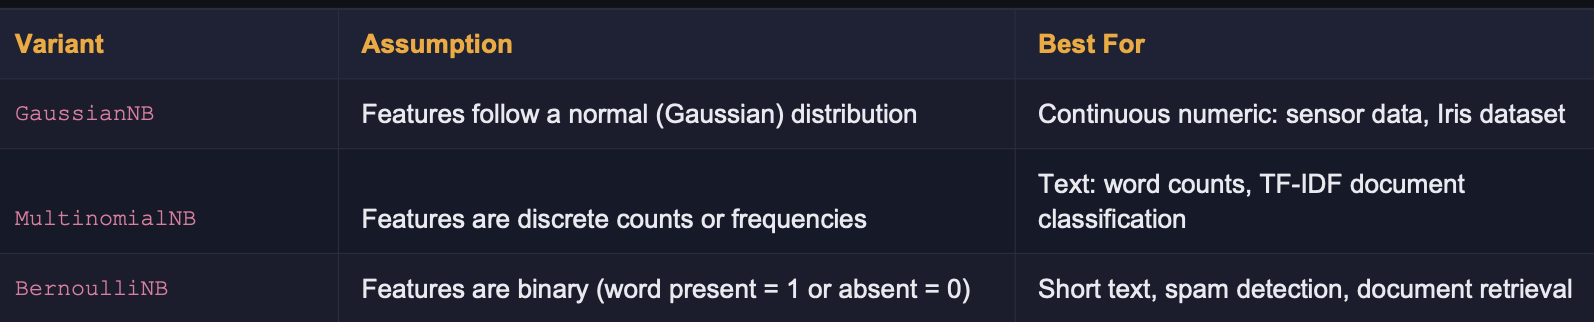

Naive Bayes Code — Spam Classifier with Pipeline

"Win ₹10000 now"

"Claim your free prize"

"Are you coming to class?"

"Let's meet tomorrow"

Machine Learning cannot understand text directly.

Text

 ↓

Numbers

 ↓

Machine Learning Model

 ↓

Spam / Ham

In [ ]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report










# ■■ Sample email dataset ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
emails = [
'Win a free iPhone now click here', # spam
'Congratulations you won a lottery prize',# spam
'FREE cash prize claim within 24 hours', # spam
'Limited offer buy now get 50 percent off', # spam
'Meeting at 3pm tomorrow please confirm', # ham
'Quarterly report attached for review', # ham
'Can you send me the project files thanks',# ham
'Team lunch tomorrow noon at cafeteria', # ham
'Urgent your account has been suspended', # spam
'Hi please review the attached document', # ham
]






labels = [1,1,1,1,0,0,0,0,1,0] # 1=spam 0=ham







X_train,X_test,y_train,y_test = train_test_split(
emails, labels, test_size=0.3, random_state=42)





# ■■ Pipeline: TF-IDF vectorise -> classify ■■■■■■■■■■■■■■■■■■■■
# TF-IDF: rare informative words get higher weight than common ones
#aas we mentioned we need to convert text to numbers for that we are going to use TF  = Term Frequency
#IDF = Inverse Document Frequency
# alpha=1.0 is Laplace smoothing — prevents zero-probability words



pipe = Pipeline([
('tfidf', TfidfVectorizer(lowercase=True, stop_words='english')),
('nb', MultinomialNB(alpha=1.0)),
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

              precision    recall  f1-score   support

         Ham       0.50      1.00      0.67         1
        Spam       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



Text Message

      ↓

TF-IDF

      ↓

Numerical Features

      ↓

Naive Bayes

      ↓
      
Spam/Ham

This pipeline first converts text into numerical TF-IDF features.
TF-IDF gives higher importance to informative rare words and lower
importance to common words.

The transformed features are then passed to a Multinomial Naive Bayes
classifier, which calculates probabilities for each class and predicts
whether a message is Ham or Spam.

Laplace smoothing (alpha=1.0) prevents zero probabilities for unseen
words. Finally, classification_report evaluates model performance using
precision, recall, and F1-score.

In [ ]:
# ■■ Inspect learned probabilities ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
nb_model = pipe.named_steps['nb']
vectorizer = pipe.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()
import numpy as np

MultinomialNB()
TfidfVectorizer(stop_words='english')
['24' '3pm' '50' 'attached' 'buy' 'cafeteria' 'cash' 'claim' 'click'
 'confirm' 'document' 'files' 'free' 'hi' 'hours' 'iphone' 'limited'
 'lunch' 'meeting' 'noon' 'offer' 'percent' 'prize' 'project' 'review'
 'send' 'team' 'thanks' 'tomorrow' 'win']


In [ ]:
# Top spam words (highest log-probability in spam class)
spam_log_probs = nb_model.feature_log_prob_[1] # class index 1 = spam

top_spam_idx = np.argsort(spam_log_probs)[-10:][::-1]
print('Top spam words:', [feature_names[i] for i in top_spam_idx])

[-3.25194799 -3.60208154 -3.23244149 -3.60208154 -3.23244149 -3.60208154
 -3.25194799 -3.25194799 -3.1829458  -3.60208154 -3.60208154 -3.60208154
 -3.02535532 -3.60208154 -3.25194799 -3.1829458  -3.23244149 -3.60208154
 -3.60208154 -3.60208154 -3.23244149 -3.23244149 -3.25194799 -3.60208154
 -3.60208154 -3.60208154 -3.60208154 -3.60208154 -3.60208154 -3.1829458 ]
Top spam words: ['free', 'win', 'iphone', 'click', 'percent', 'offer', 'buy', 'limited', '50', 'cash']


In [ ]:
# ■■ Predict new emails with confidence ■■■■■■■■■■■■■■■■■■■■■■■■
new = ['  your       its a new job its been great well working this is example for spuerwhjhfv']
for email, pred, prob in zip(new, pipe.predict(new), pipe.predict_proba(new)):
  print(f'[{"SPAM" if pred==1 else "HAM"}] conf={prob[pred]*100:.1f}% {email}')

[HAM] conf=57.1%   your       its a new job its been great well working this is example for spuerwhjhfv


Feature Scaling — Why It Matters

The Problem Without Scaling

uppose your dataset has two features: Age (range 20–65) and Salary (range 20,000–1,20,000). KNN
computes Euclidean distance between two people as:

d = sqrt( (age1-age2)^2 + (salary1-salary2)^2 )

An age difference of 5 years contributes 25 to the sum. A salary difference of just 500 rupees contributes
2,50,000. The salary term completely dominates. KNN becomes a salary-only classifier and ignores age
entirely. Feature scaling fixes this

StandardScaler — Standardisation

Centres the data around zero mean with unit standard deviation. Each feature independently becomes: how
many standard deviations away from the mean is this value?

z = (x - mean(x)) / std(x)

Result: feature mean = 0, feature std = 1. Values are typically in the range [-3, +3]. Outliers are present but scaled
down. This is the most commonly used scaler.

MinMaxScaler — Normalisation

Squeezes all values into a fixed range, typically [0, 1]. Preserves the original distribution shape but is sensitive to
outliers (a single extreme value compresses all other values into a tiny range).

x_scaled = (x - x_min) / (x_max - x_min)

Use when: the algorithm explicitly needs [0,1] inputs, or you know there are no outliers in the data. Common in
neural networks with sigmoid activation functions.

RobustScaler — Outlier-Resistant Scaling

Uses the median and interquartile range (IQR) instead of mean and std. Because the median and IQR are not
affected by extreme values, this scaler is robust when your data has significant outliers.

x_scaled = (x - median(x)) / IQR(x) where IQR = Q3 - Q1

Comparison of Scalers

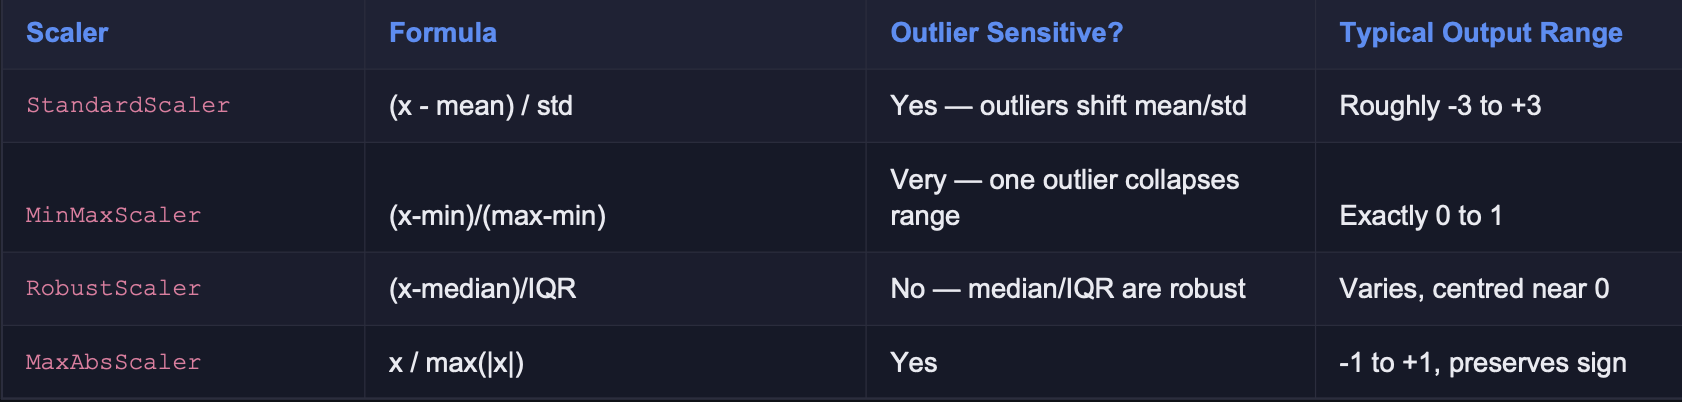

The Golden Rule: Fit on Train, Transform Both

Data Leakage Warning

The scaler must learn its parameters (mean, std, min, max) from the training data only. You then apply those
same learned parameters to transform the test set.

If you fit the scaler on the full dataset (train + test), the test mean and std influence the transformation. Your
model has effectively peeked at test data statistics before evaluation. This is called data leakage and inflates
your reported accuracy.

Correct pattern: scaler.fit_transform(X_train) then scaler.transform(X_test)

Feature Scaling Code

In [ ]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# ■■ Demo: age vs salary ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
data = pd.DataFrame({'age':[22,35,47,60,18,55,30,42,25,50],
'salary':[25000,50000,75000,95000,18000,88000,42000,65000,30000,72000],
'bought':[0,1,1,1,0,1,0,1,0,1]})
X = data[['age','salary']].values; y = data['bought'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [ ]:
# ■■ Apply all three scalers ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
ss = StandardScaler()
mm = MinMaxScaler()
rb = RobustScaler()
X_std = ss.fit_transform(X_train) # fit on train, transform train
X_mm = mm.fit_transform(X_train)
X_rb = rb.fit_transform(X_train)
X_test_std = ss.transform(X_test) # only transform test, never fit
print(f'Original Age: {X_train[:,0].min():.0f} to {X_train[:,0].max():.0f}')
print(f'Standard Age: {X_std[:,0].min():.2f} to {X_std[:,0].max():.2f}')
print(f'MinMax Age: {X_mm[:,0].min():.2f} to {X_mm[:,0].max():.2f}')

Original Age: 22 to 60
Standard Age: -1.56 to 1.40
MinMax Age: 0.00 to 1.00


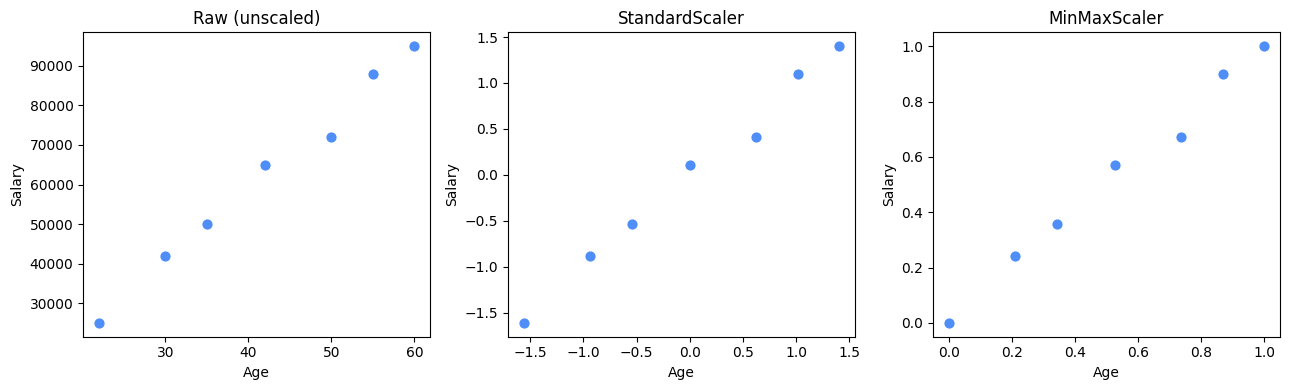

In [ ]:
# ■■ Visualise effect of scaling ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax,X_s,title in zip(axes,[X_train,X_std,X_mm],
  ['Raw (unscaled)','StandardScaler','MinMaxScaler']):
  ax.scatter(X_s[:,0],X_s[:,1],c='#4F8EF7',s=70,edgecolor='white')
  ax.set_title(title); ax.set_xlabel('Age'); ax.set_ylabel('Salary')
plt.tight_layout(); plt.show()

In [ ]:
# ■■ Effect on KNN decision boundary ■■■■■■■■■■■■■■■■■■■■■■■■■■
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for name, Xtr, Xte in [('Unscaled', X_train, X_test),
  ('StandardScaler', X_std, X_test_std)]:
  knn = KNeighborsClassifier(n_neighbors=3)
  knn.fit(Xtr, y_train)
  acc = accuracy_score(y_test, knn.predict(Xte))
  print(f'{name:>15} KNN accuracy: {acc:.2f}')

       Unscaled KNN accuracy: 1.00
 StandardScaler KNN accuracy: 1.00


Lab — MNIST Handwritten Digit Recognition

What is MNIST?

MNIST contains 70,000 grayscale 28x28 pixel images of handwritten digits (0-9). Each image flattens to a
vector of 784 pixel values (0-255). We treat each pixel as a feature — KNN classifies a new digit by finding the
K most visually similar training images and taking a vote.

Why MNIST is a Good KNN Test


KNN works by geometric proximity — similar digits look visually similar, meaning their pixel vectors are close in
784-dimensional space. A handwritten '7' in the test set should sit near the '7' images in training. The challenge is
that '1' and '7', or '4' and '9', can look similar — this shows up clearly in the confusion matrix.

Full Pipeline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.datasets import fetch_openml # Commenting out problematic import
import tensorflow as tf # Import TensorFlow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# ■■ Load MNIST using tf.keras.datasets (more robust) ■■■■■■■■■■■
print('Loading MNIST dataset...')
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Combine train and test for consistent processing as per original fetch_openml output structure
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Flatten the images from 28x28 to 784 features
X = X.reshape(X.shape[0], -1)

print(f'Full dataset: {X.shape}') # (70000, 784)
# Ensure y is integer type, as fetch_openml does
y = y.astype(int)

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full dataset: (70000, 784)


In [ ]:
# ■■ Use 10,000 samples (full set takes ~10 min to predict) ■■■■
X, y = X[:10000], y[:10000]
X_train,X_test,y_train,y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape} Test: {X_test.shape}')

Train: (8000, 784) Test: (2000, 784)


In [ ]:
# ■■ Scale pixels 0-255 to standardised values ■■■■■■■■■■■■■■■■■
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train.astype(float))
Xte_s = scaler.transform(X_test.astype(float))

In [ ]:
# ■■ Train KNN (ball_tree is faster for high-dim data) ■■■■■■■■■
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean',
algorithm='ball_tree', n_jobs=-1)
knn.fit(Xtr_s, y_train)

KNeighborsClassifier(algorithm='ball_tree', metric='euclidean', n_jobs=-1)

In [ ]:
# ■■ Evaluate ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = knn.predict(Xte_s)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(classification_report(y_test, y_pred))

Test Accuracy: 90.50%
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       200
           1       0.87      0.99      0.93       225
           2       0.91      0.84      0.87       198
           3       0.89      0.92      0.90       206
           4       0.93      0.85      0.89       196
           5       0.91      0.89      0.90       173
           6       0.95      0.95      0.95       203
           7       0.92      0.87      0.89       214
           8       0.93      0.83      0.88       189
           9       0.85      0.91      0.88       196

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.90      2000



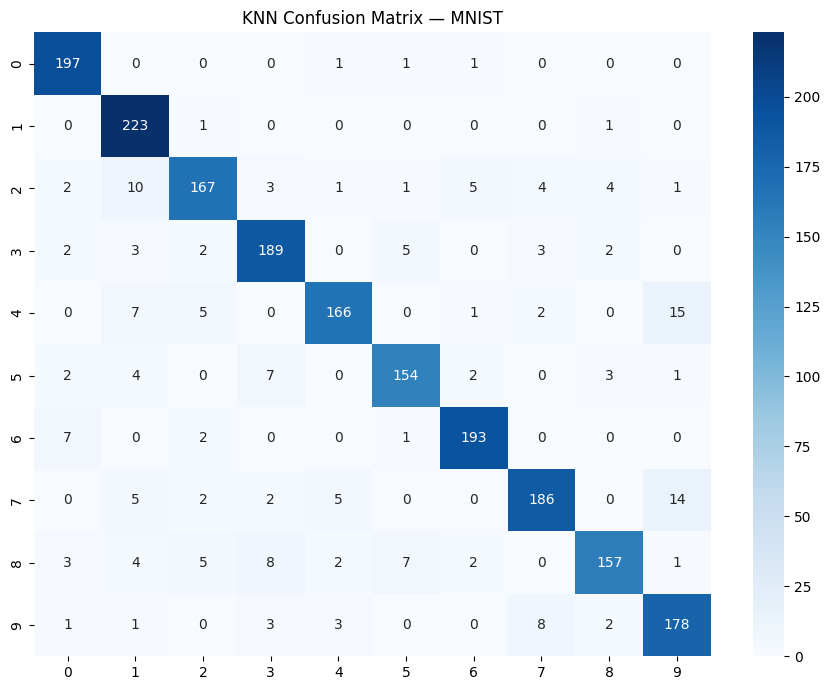

In [ ]:
# ■■ Confusion matrix ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title('KNN Confusion Matrix — MNIST'); plt.tight_layout(); plt.show()

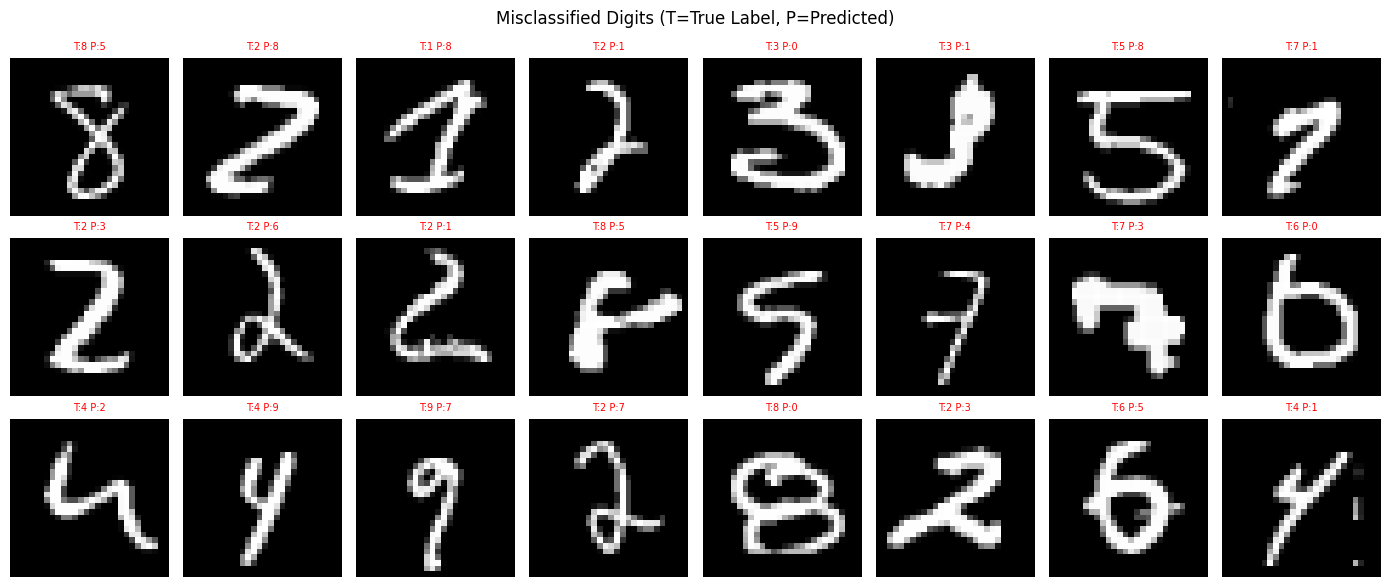

In [ ]:
# ■■ Show misclassified images ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
wrong = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(3,8,figsize=(14,6))
for i,ax in enumerate(axes.flat):
  if i < len(wrong):
    ax.imshow(X_test[wrong[i]].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[wrong[i]]} P:{y_pred[wrong[i]]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True Label, P=Predicted)')
plt.tight_layout(); plt.show()

In [ ]:
# ■■ Compare K values ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
for k in [1,3,5,7,9]:
  kk = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
  kk.fit(Xtr_s, y_train)
print(f'K={k} Accuracy={accuracy_score(y_test, kk.predict(Xte_s))*100:.2f}%')

K=9 Accuracy=90.70%
